### Random forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from pprint import pprint
from sklearn import preprocessing
from sklearn.utils import shuffle
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

In [2]:
# my functions
from prepare_data import create_dataframe
from random_forest import train_rf_diff_aggr, evaluate, RF_pred_vs_true, RF_features_importance

#### Random forest model with data collected at 8 hour time intervals and aggregated with spatial precision = 5

In [8]:
df = create_dataframe(aggr_freq = '8H', precision = 5, aggr_function = 'median')

In [9]:
# apply one-hot encoding, data scaling and normalization
# get dummies (one-hot encoding for categorical feature - cell_code)
df = pd.get_dummies(df)
# shuffle the data
df = shuffle(df, random_state=42)

In [10]:
# split train and test, with 75% train, 25% test
X_train, X_test, y_train, y_test = train_test_split(df.drop('trips_count', axis=1), df.trips_count, test_size=0.25, random_state=42)

In [11]:
# normalize data (except cell_code) - using each column mean and sd in the TRAIN set
# compute mean and std on training data

# normalize features based on TRAIN mean and std of the respective column
for col in X_train.columns.drop(list(df.filter(regex='cell_code'))):
    avg = X_train[col].mean()
    std = X_train[col].std()
    X_train[col] = (X_train[col] - avg) / std
    X_test[col] = (X_test[col] - avg) / std

# normalize target based on TRAIN mean and std
trips_cnt_avg = y_train.mean()
trips_cnt_std = y_train.std()
y_train = (y_train - trips_cnt_avg) / trips_cnt_std
y_test = (y_test - trips_cnt_avg) / trips_cnt_std

In [12]:
# base-RF-model
rf = RandomForestRegressor(random_state = 42)

print('Parameters currently in use:\n')

pprint(rf.get_params())

Parameters currently in use:

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}


### *Hyperparameter tuning*:

The description of the most important parameters, according to the [sklearn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html), is:
- n_estimators = number of trees in the forest
- max_features = max number of features considered for splitting a node
- max_depth = max number of levels in each decision tree
- min_samples_split = min number of data points placed in a node before the node is split
- min_samples_leaf = min number of data points allowed in a leaf node
- bootstrap = method for sampling data points (with or without replacement)

#### Randomized Search 

In [13]:
# possibilities for the number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 10, stop = 500, num = 10)]
# options for the number of features to consider at every split
max_features = ['log2', 'sqrt', 'auto', 2, 6, 10, 15, None]
# maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
# minimum number of samples required to split a node
min_samples_split = [30, 50, 100, 200, 500] 
# minimum number of samples required at each leaf node
min_samples_leaf = [20, 30, 50, 100, 200, 500] 
# method of selecting samples for training each tree
bootstrap = [True, False]

# create the random grid: at each iteration, the algorithm will choose a different
# combination of the features. The advantage of the random search method is that we are not 
# trying every combination, but selecting randomly to sample a wide range of values.
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

In [14]:
# use the random grid to search for best hyperparameters:

# create the base model to tune:
rf = RandomForestRegressor()
# implement random search of parameters, using 5 fold Cross Validation
# important arguments to specify in RandomizedSearchCV: 
# n_iter --> the number of different combinations to try --> more iterations will cover a wider search space
# cv --> number of folds to use for cross validation --> more cv folds reduces the chances of overfitting 
# However, increasing these parameters will increase the run time
rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 100, cv = 5, verbose = 2, random_state = 42, n_jobs = -1)

# fit the random search model
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, 110,
                                                      None],
                                        'max_features': ['log2', 'sqrt', 'auto',
                                                         2, 6, 10, 15, None],
                                        'min_samples_leaf': [20, 30, 50, 100,
                                                             200, 500],
                                        'min_samples_split': [30, 50, 100, 200,
                                                              500],
                                        'n_estimators': [10, 64, 118, 173, 227,
                                                         282, 336, 391, 445,
                                                         500]},
                   random_state=42, verbose=2)

In [15]:
# best parameters resulting from random search
rf_random.best_params_

{'n_estimators': 64,
 'min_samples_split': 30,
 'min_samples_leaf': 20,
 'max_features': 15,
 'max_depth': None,
 'bootstrap': False}

Random forest model performance evaluation (optimized vs base model with default parameters).

Evaluate the gaining in performance after optmizing the model parameters w/ random search or grid search.

In [29]:
base_model = RandomForestRegressor(n_estimators = 10, random_state = 42)
base_model.fit(X_train, y_train)
base_metrics = evaluate(base_model, X_test, y_test, trips_cnt_avg, trips_cnt_std)
print('Base Model:\n', 'avg.error: ', base_metrics['avg. errors'], '\n', 'MAE: ', base_metrics['mae'], '\n', 'MSE: ', base_metrics['mse'], '\n', 'MAPE: ', base_metrics['mape'])


rs_model = rf_random.best_estimator_
random_metrics = evaluate(rs_model, X_test, y_test, trips_cnt_avg, trips_cnt_std)
print('\nModel after Random Search:\n', 'avg.error: ', random_metrics['avg. errors'], '\n', 'MAE: ', random_metrics['mae'], '\n', 'MSE: ', random_metrics['mse'], '\n', 'MAPE: ', random_metrics['mape'])

Base Model:
 avg.error:  2.880964575330774 
 MAE:  2.880964575330773 
 MSE:  39.054993597951345 
 MAPE:  885727148225492.2

Model after Random Search:
 avg.error:  3.0351960351784295 
 MAE:  3.0351960351784255 
 MSE:  43.639439298837296 
 MAPE:  1487913378340510.5

Improvement of 67.99%.


Grid Search is a more exhaustive approach to optimize parameters as it look for all possible combinations. The two methods can be combined: after narrowing hyperparameters search space using random search, we can explicitely look at every combinations of the remained settings to try to find the optimal one, via GridSearchCV.

In [24]:
rf_random.best_params_

{'n_estimators': 64,
 'min_samples_split': 30,
 'min_samples_leaf': 20,
 'max_features': 15,
 'max_depth': None,
 'bootstrap': False}

In [33]:
# GridSearchCV evaluates ALL possible combinations of passed hyperparameters,
# in this case, the best ones resulting from random search,
# thus create a grid with the best values provided by RandomSearchCV

param_grid = {'n_estimators': [44, 54, 64], 
 'min_samples_split': [20, 30], 
 'min_samples_leaf': [15, 20, 25],
 'max_features': ['sqrt', 15, None],
 'max_depth': [20, 30, 40, None],
 'bootstrap': [False]
}

# initialize random forest
rf = RandomForestRegressor()
# initialize grid search
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid, cv = 5, n_jobs = -1, verbose = 2)
# perform grid search
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'bootstrap': [False], 'max_depth': [20, 30, 40, None],
                         'max_features': ['sqrt', 15, None],
                         'min_samples_leaf': [15, 20, 25],
                         'min_samples_split': [20, 30],
                         'n_estimators': [44, 54, 64]},
             verbose=2)

In [34]:
# grid search best parameters
grid_search.best_params_

{'bootstrap': False,
 'max_depth': None,
 'max_features': 15,
 'min_samples_leaf': 15,
 'min_samples_split': 30,
 'n_estimators': 54}

In [35]:
best_grid = grid_search.best_estimator_
grid_metrics = evaluate(best_grid, X_test, y_test, trips_cnt_avg, trips_cnt_std)
print('\nModel after Random Search:\n', 'avg.error: ', grid_metrics['avg. errors'], '\n', 'MAE: ', grid_metrics['mae'], '\n', 'MSE: ', grid_metrics['mse'], '\n', 'MAPE: ', grid_metrics['mape'])


Model after Random Search:
 avg.error:  2.9367204477733204 
 MAE:  2.9367204477733138 
 MSE:  40.89154142758437 
 MAPE:  1334953365788013.2


In [36]:
print('Grid Search:\nMAE: ', grid_metrics['mae'], '\nMSE: ', grid_metrics['mse'])
print('\nRandom Search:\nMAE: ', random_metrics['mae'], '\nMSE: ', random_metrics['mse'])

Grid Search:
MAE:  2.9367204477733138 
MSE:  40.89154142758437

Random Search:
MAE:  3.0351960351784255 
MSE:  43.639439298837296


In [37]:
# select model with best performances 
print('Final Model Parameters:\n')
final_model = grid_search.best_estimator_ # rf_random
pprint(final_model.get_params())

Final Model Parameters:

{'bootstrap': False,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 15,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 15,
 'min_samples_split': 30,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 54,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}


#### Final Random Forest Model

In [40]:
# apply the final model with parameters optimized
rf = final_model 
rf.fit(X_train, y_train)
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)   

# evaluation metrics
print('Performance on TRAIN set:')
train_metrics = evaluate(rf, X_train, y_train, trips_cnt_avg, trips_cnt_std)
print(train_metrics)
print('Performance on TEST set:')
test_metrics = evaluate(rf, X_test, y_test, trips_cnt_avg, trips_cnt_std)
print(test_metrics)

Performance on TRAIN set:
{'mae': 2.3251366346012032, 'mse': 23.446897696929565, 'rmse': 4.842199675450153, 'mape': 1035990101770647.4}
Performance on TEST set:
{'mae': 2.9550144389033073, 'mse': 41.33625111995314, 'rmse': 6.429327423607631, 'mape': 1353902487124344.8}


In [41]:
# denormalize
y_test_orig = y_test * trips_cnt_std + trips_cnt_avg
y_test_pred_orig = y_test_pred * trips_cnt_std + trips_cnt_avg

Text(0, 0.5, 'trips_count')

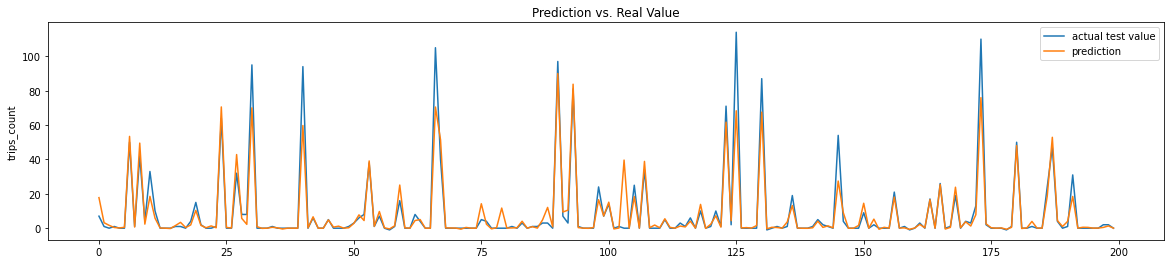

In [42]:
# plt.style.use('fivethirtyeight')

plt.figure(figsize=(20,4))
plt.plot(y_test_orig[900:1100].values, label="actual test value")
plt.plot(y_test_pred_orig[900:1100], label="prediction")
plt.legend()
plt.title("Prediction vs. Real Value", color='black')
plt.xlabel("")
plt.ylabel("trips_count")

In [88]:
# save the model:
# import joblib
# joblib.dump(rf, "RF_EScooterDemandPrediction_AllFeatures.sav")

Text(0.5, 1.0, 'Feature Importance')

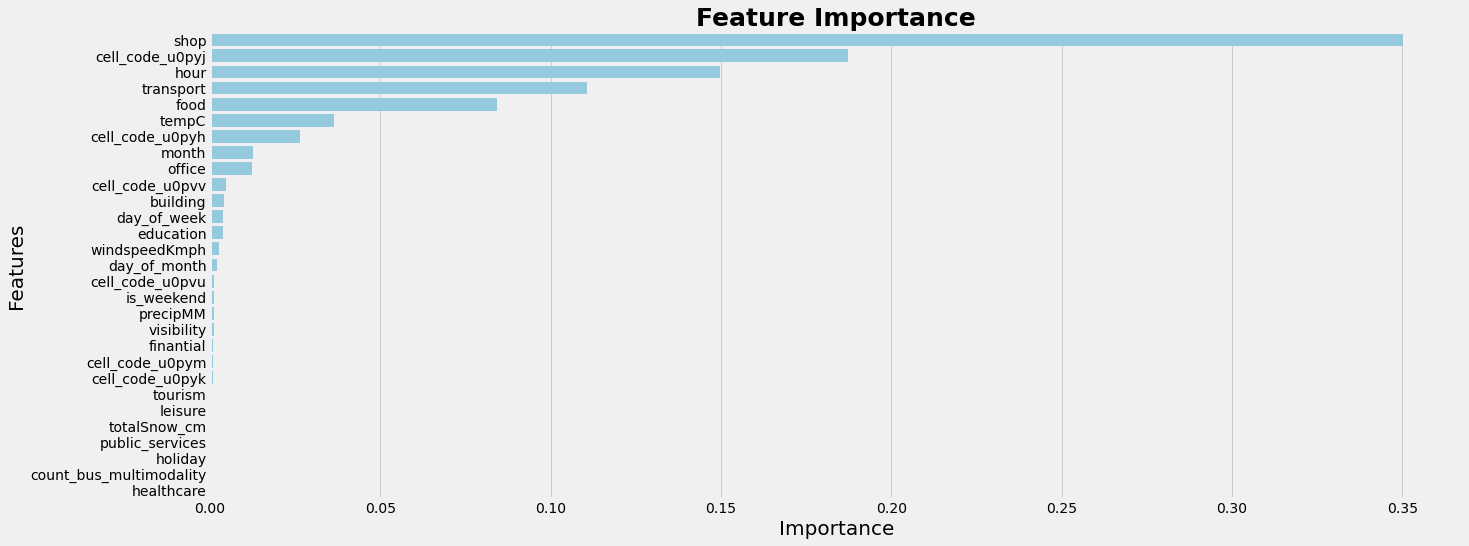

In [43]:
# check which features are the most important in the random forest model
feats = {}
for feature, importance in zip(X_train.columns, rf.feature_importances_):
    feats[feature] = importance
importances = pd.DataFrame.from_dict(feats, orient='index').rename(columns={0: 'Gini-Importance'})
importances = importances.sort_values(by='Gini-Importance', ascending=False)
importances = importances.reset_index()
importances = importances.rename(columns={'index': 'Features'})

plt.style.use('fivethirtyeight')

plt.figure(figsize=(20,8))
sns.barplot(x=importances['Gini-Importance'], y=importances['Features'], data=importances, color='skyblue')
plt.xlabel('Importance', fontsize=20)
plt.ylabel('Features', fontsize=20)
plt.title('Feature Importance', fontsize=25, weight = 'bold')

Text(0.5, 1.0, 'Cumulative Importances')

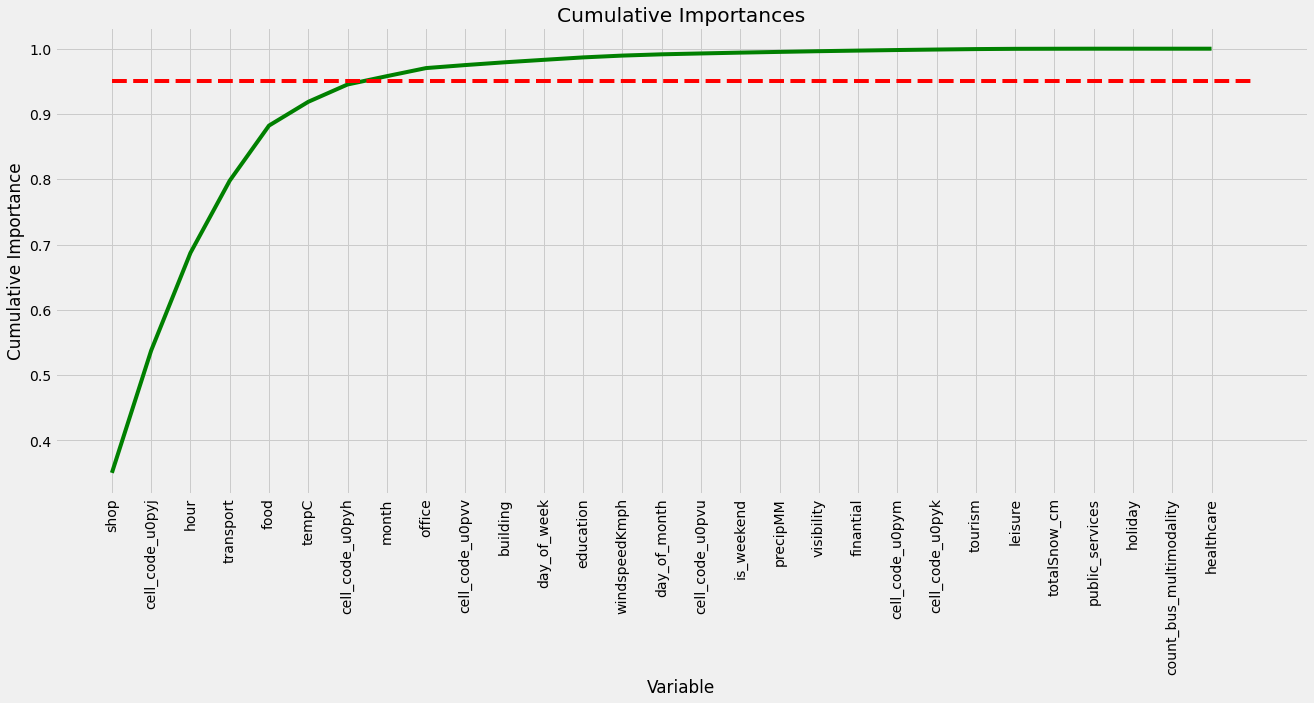

In [44]:
# Cumulative Importance
cumulative_importances = np.cumsum(importances['Gini-Importance'])

plt.figure(figsize=(20,8))

# line graph
plt.plot(X_train.columns, cumulative_importances, 'g-')

# draw line at 95% of importance:
plt.hlines(y = 0.95, xmin=0, xmax=len(importances['Features']), color = 'r', linestyles = 'dashed')

plt.xticks(X_train.columns, importances['Features'], rotation = 'vertical')
plt.xlabel('Variable')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Importances')

The importance of the feature confrims previoius analysis, as the most important predictors of trips are:
 - the proximity to POIs belonging to shop, transport, and food categories: this was seen also in the *trips purposes* analysis, where we noticed that riders have the tendency of using these vehicles to move among these types of places;
 - hour, as the time-interval play an important role in the prediction;
 - temperature, which confirm the influence of the weather on the demand, expecially in relations to the degrees;
 - blocks *u0pyj* (center-east) and *u0pyh* (center-west) seems to be the ones with greater influence on the demand. When comparing the codes with their location on the [map](http://www.movable-type.co.uk/scripts/geohash.html), one will notice that these blocks are located in the central part of the city, where the greatest number of attractions are located, with high variaty of POIs types. This confirms previous considerations on the attractive power of the regions, showing how these areas of the city have greatest potential in generating trips, if compared with others.

#### Select most important features only
Check if performances improve by using only the most important features (95% level reached):

In [45]:
# most impo feats
list(df[importances['Features'].to_list()[:7]].columns)

['shop',
 'cell_code_u0pyj',
 'hour',
 'transport',
 'food',
 'tempC',
 'cell_code_u0pyh']

In [ ]:
X = df[importances['Features'].to_list()[:7]] # select most impo feats only
y = df.trips_count

# split train and test
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.25, random_state=42)

# random search
rf_feat = RandomForestRegressor()
rf_random_2 = RandomizedSearchCV(estimator = rf_feat, param_distributions = random_grid, n_iter = 100, cv = 5, verbose = 2, random_state = 42, n_jobs = -1)
rf_random_2.fit(X_train2, y_train2)

In [93]:
rf_random_2.best_params_

{'n_estimators': 391,
 'min_samples_split': 30,
 'min_samples_leaf': 20,
 'max_features': 2,
 'max_depth': 110,
 'bootstrap': False}

In [94]:
# random forest with only the most important features
rf_most_important = rf_random_2.best_estimator_
rf_most_important.fit(X_train2, y_train2)

RandomForestRegressor(bootstrap=False, max_depth=110, max_features=2,
                      min_samples_leaf=20, min_samples_split=30,
                      n_estimators=391)

In [95]:
metrics_most_impo_feats = evaluate(rf_most_important, X_test2, y_test2)
metrics_most_impo_feats

{'avg. errors': 3.658588857099298,
 'mae': 3.6585888570993,
 'mse': 49.99551768215618,
 'rmse': 7.0707508570275746,
 'mape': 2688525835300467.5,
 'accuracy_percentage': -2.6885258353004666e+17}

Removing features declines a lot the model's performance and explainatory power.

In [47]:
# previous metrics (with all features)
random_metrics

{'avg. errors': 3.0351960351784295,
 'mae': 3.0351960351784255,
 'mse': 43.639439298837296,
 'rmse': 6.606015387420566,
 'mape': 1487913378340510.5,
 'accuracy_percentage': -1.4879133783405094e+17}

#### Train model with different levels of spatio-temporal aggregation

In [ ]:
# 8 hours interval - precision 5
# performed in the example above
# train_rf_diff_aggr(aggr_freq = '8H', precision = 5)

In [ ]:
# 8 hours interval - precision 6
rf_8H_prec6, metrics_8H_prec6, X_train, X_test, y_train, y_test, avg, s = train_rf_diff_aggr(aggr_freq = '8H', precision = 6)

predictions = rf_8H_prec6.predict(X_test)
RF_pred_vs_true(y_test, predictions, avg, s)
RF_features_importance(rf_8H_prec6, X_train.columns)

In [ ]:
metrics_8H_prec6

Fitting 5 folds for each of 100 candidates, totalling 500 fits


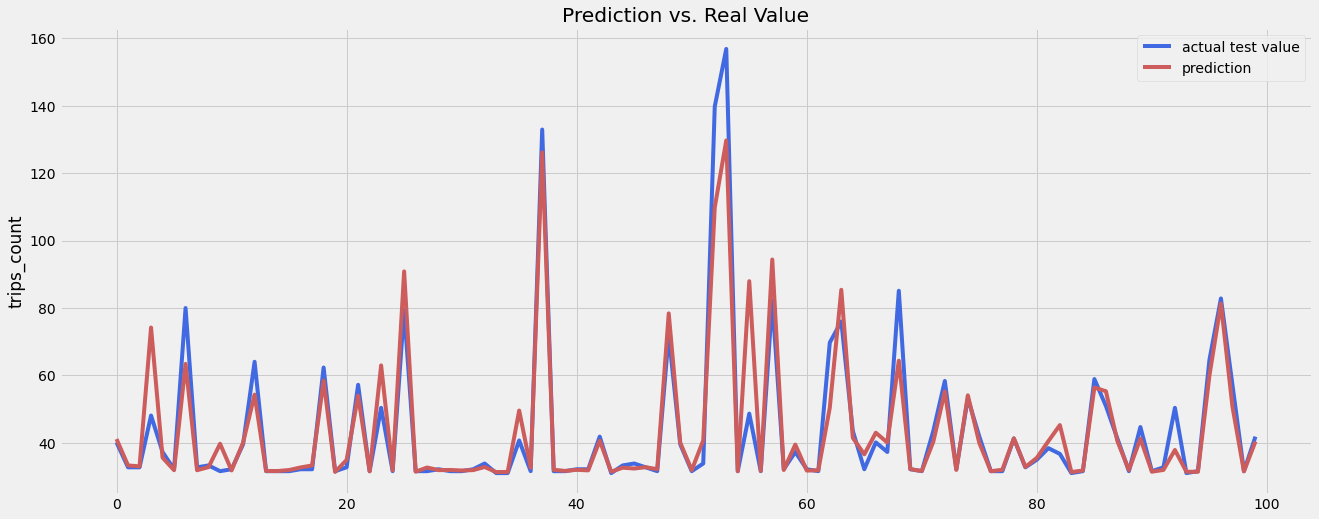

In [50]:
# daily models with wide grid
rf_D_prec5, metrics_D_prec5, X_train, X_test, y_train, y_test, avg5, std5 = train_rf_diff_aggr(aggr_freq = 'D', precision = 5)

predictions = rf_D_prec5.predict(X_test)
RF_pred_vs_true(y_test, predictions, avg5, std5)

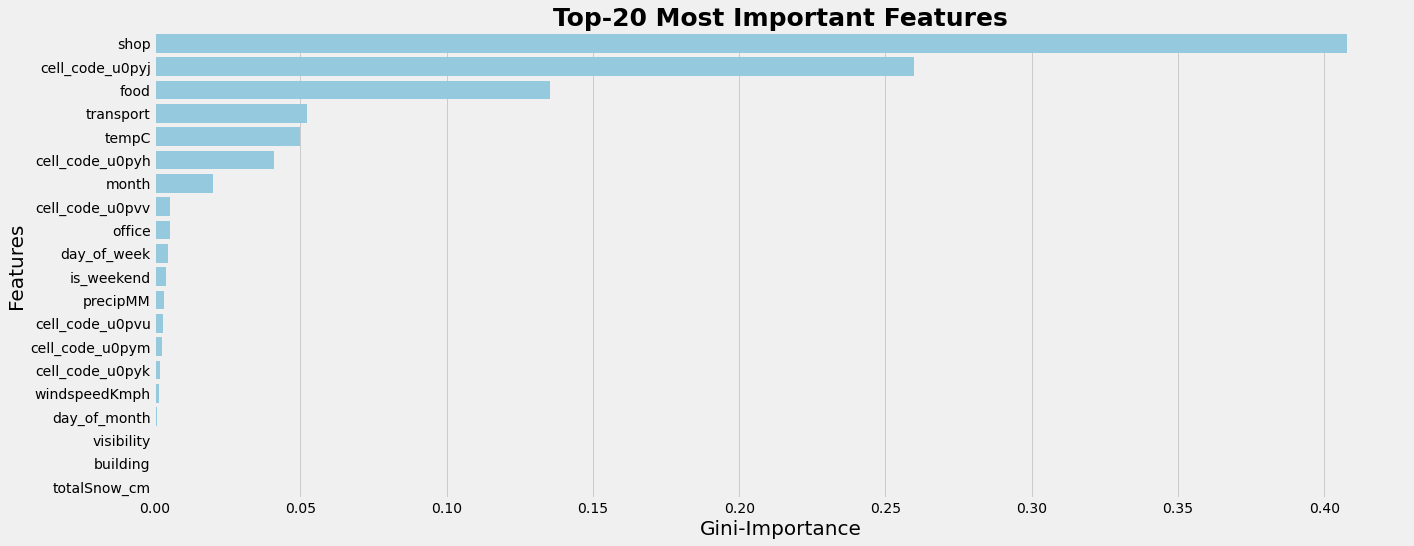

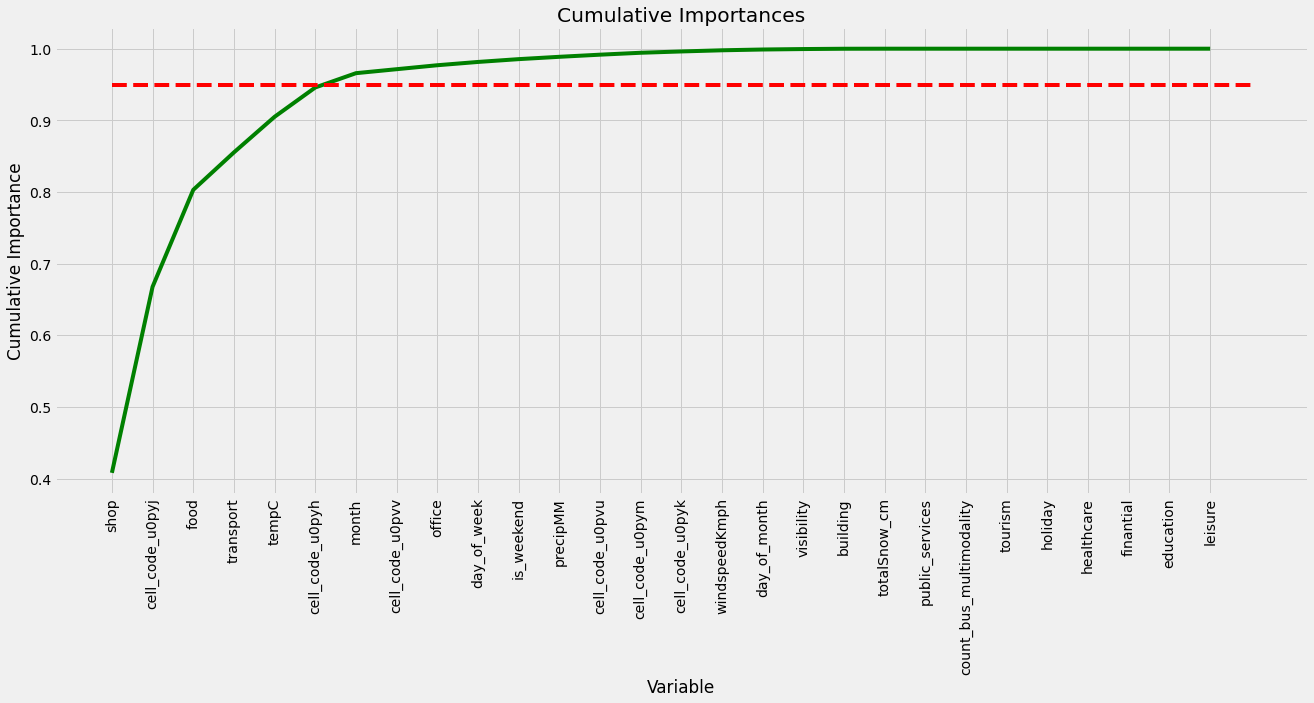

In [51]:
RF_features_importance(rf_D_prec5, X_train.columns)

In [52]:
metrics_D_prec5

{'mae': 7.523763297474568,
 'mse': 236.7820340717863,
 'rmse': 15.38772348568125,
 'mape': 2779125829800826.0}

In [ ]:
# daily models with narrow grid
rf_D_prec6, metrics_D_prec6, X_train, X_test, y_train, y_test, avg6, std6 = train_rf_diff_aggr(aggr_freq = 'D', precision = 6)

In [ ]:
metrics_D_prec6

In [ ]:
predictions = rf_D_prec6.predict(X_test)
RF_pred_vs_true(y_test, predictions, avg6, std6)
RF_features_importance(rf_D_prec6, X_train.columns)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


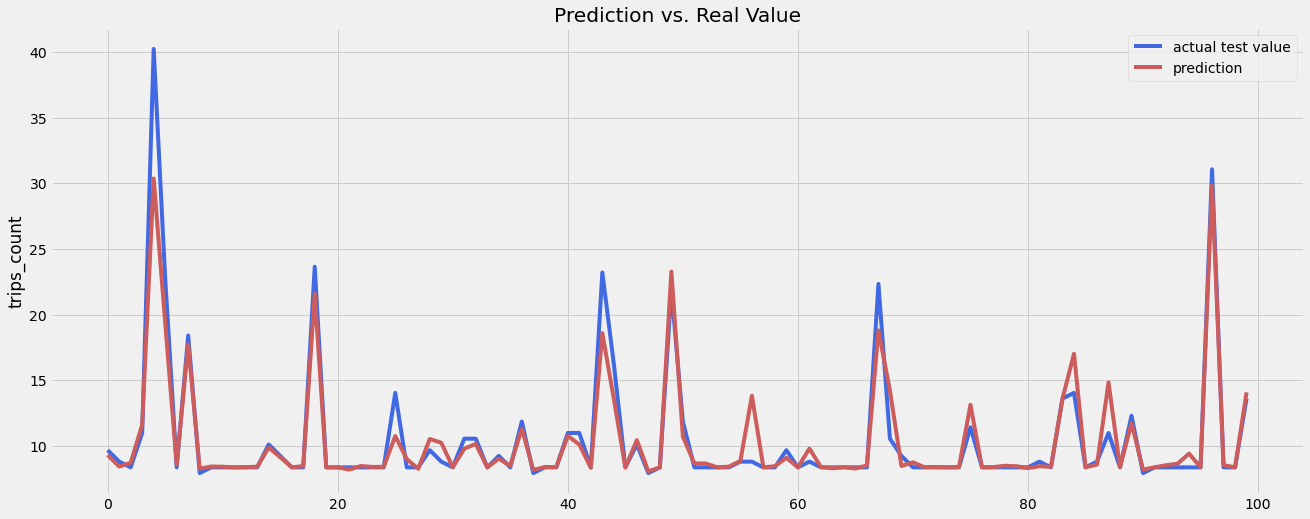

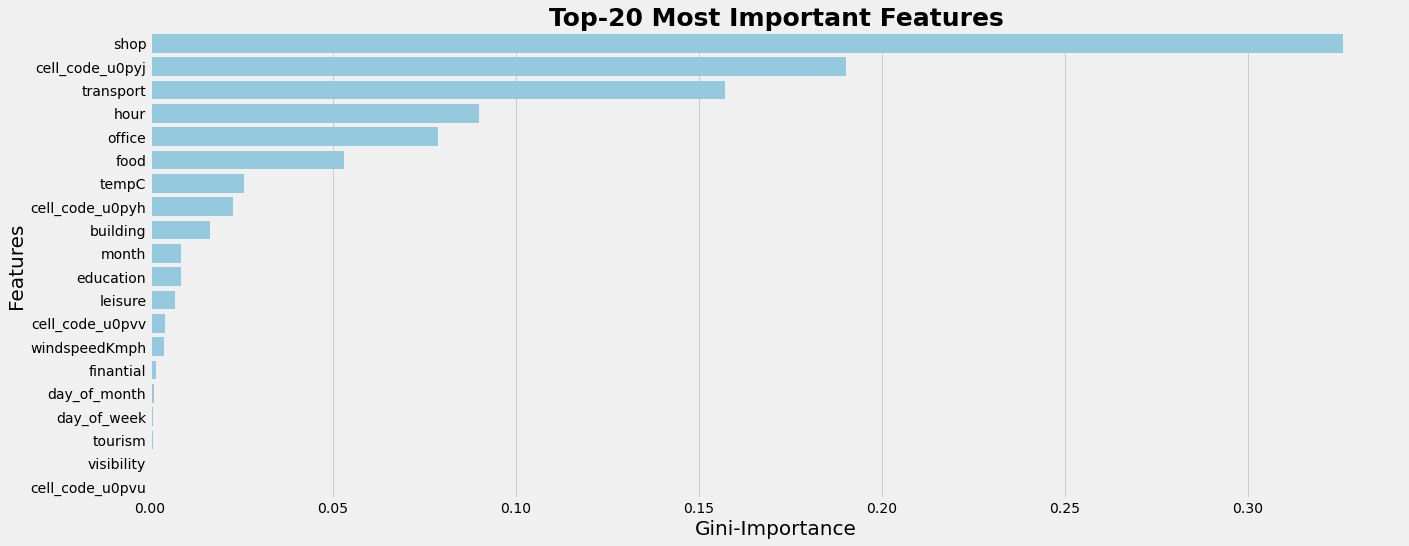

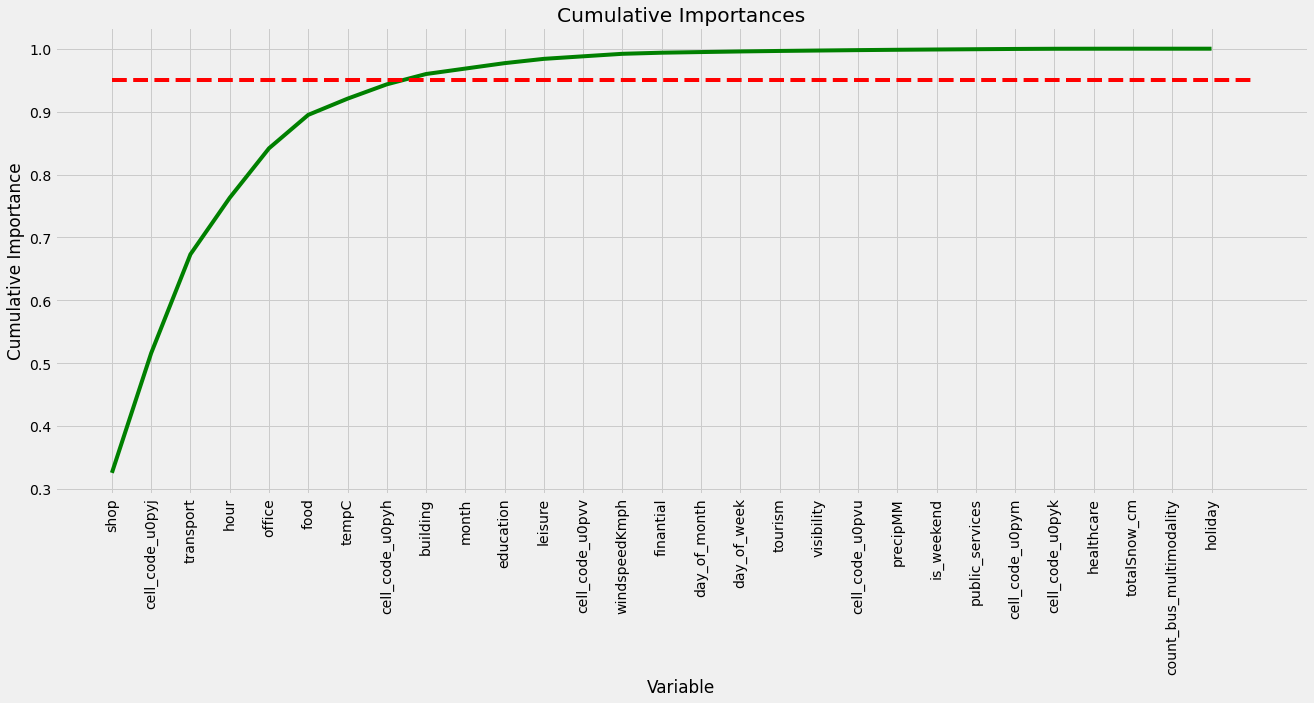

In [53]:
# 4 hours interval aggregation - both grids used
rf_4H_prec5, metrics_4H_prec5, X_train, X_test, y_train, y_test, avg4h5, std4h5 = train_rf_diff_aggr(aggr_freq = '4H', precision = 5)
predictions = rf_4H_prec5.predict(X_test)
RF_pred_vs_true(y_test, predictions, avg4h5, std4h5)
RF_features_importance(rf_4H_prec5, X_train.columns)

In [ ]:
rf_4H_prec6, metrics_4H_prec6, X_train, X_test, y_train, y_test, avg4h6, std4h6 = train_rf_diff_aggr(aggr_freq = '4H', precision = 6)
predictions = rf_4H_prec6.predict(X_test)
RF_pred_vs_true(y_test, predictions, avg4h6, std4h6)
RF_features_importance(rf_4H_prec6, X_train.columns)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


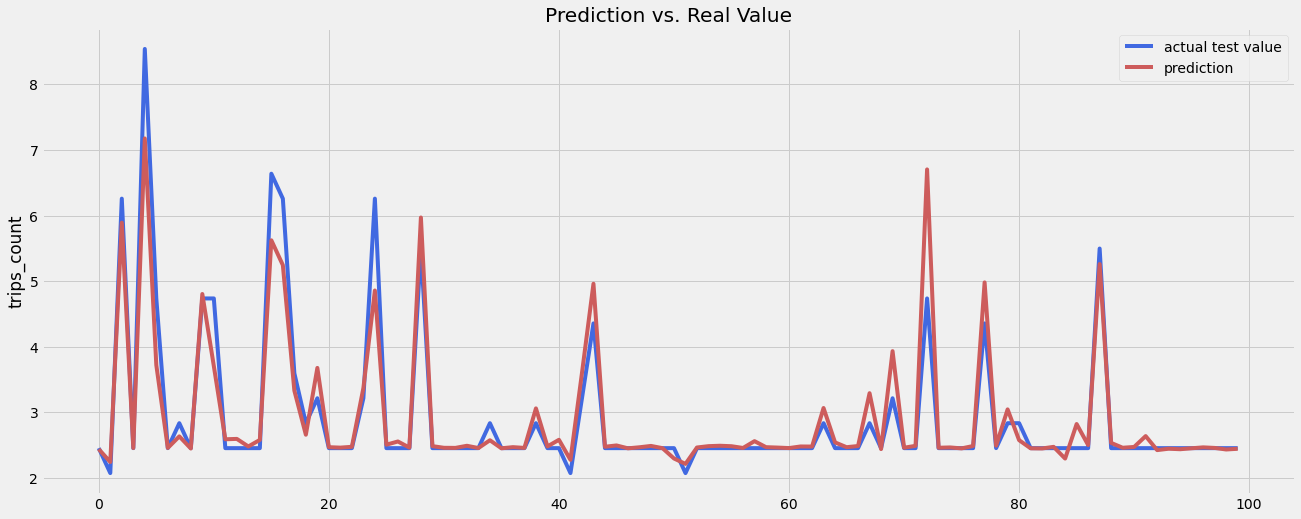

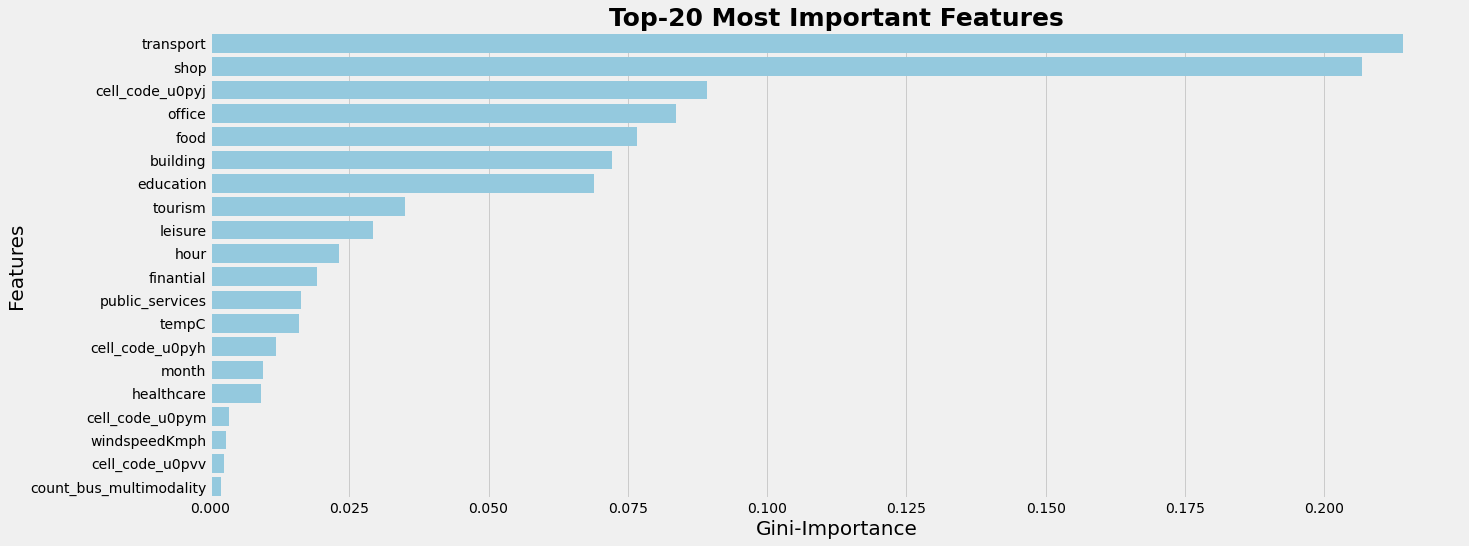

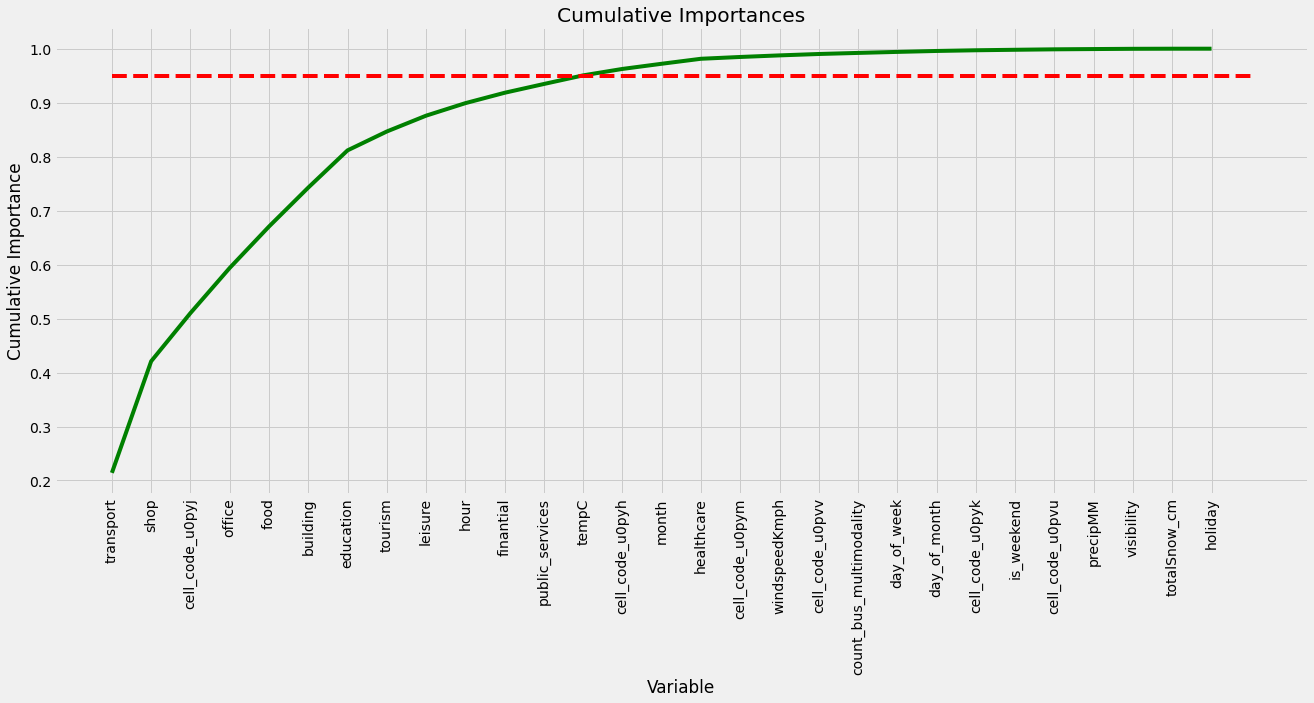

In [54]:
# 1 hours interval - precision 5 & 6
grid = {'n_estimators': [64],
        'max_features': ['log2', 'sqrt', 'auto', 2, 6, 10, 15, None],
        'max_depth': [20, 50, 100],
        'min_samples_split': [20, 30],
        'min_samples_leaf': [20, 30],
        'bootstrap': [True, False]}
rf_1H_prec5, metrics_1H_prec5, X_train, X_test, y_train, y_test, avgh5, stdh5 = train_rf_diff_aggr(aggr_freq = 'H', precision = 5, grid = grid)
predictions = rf_1H_prec5.predict(X_test)
RF_pred_vs_true(y_test, predictions, avgh5, stdh5)
RF_features_importance(rf_1H_prec5, X_train.columns)

In [ ]:
grid = {'n_estimators': [64],
        'max_features': [2, 6, 10, 15],
        'max_depth': [30],
        'min_samples_split': [20],
        'min_samples_leaf': [20],
        'bootstrap': [True, False]}

rf_1H_prec6, metrics_1H_prec6, X_train, X_test, y_train, y_test, avgh6, stdh6 = train_rf_diff_aggr(aggr_freq = 'H', precision = 6, grid = grid)
predictions = rf_1H_prec6.predict(X_test)
RF_pred_vs_true(y_test, predictions, avgh6, stdh6)
RF_features_importance(rf_1H_prec6, X_train.columns)

#### Compare models performances

In [55]:
print( 'MAE, MSE & MAPE:\n\n'
    '8H - prec=5\n', random_metrics['mae'], '\n', random_metrics['mse'], '\n', random_metrics['mape'], # 8H - prec=5
    # '\n8H - prec=6\n', metrics_8H_prec6['mae'], '\n', metrics_8H_prec6['mse'], '\n', metrics_8H_prec6['mape'], # 8H - prec=6
    '\ndaily - prec=5\n', metrics_D_prec5['mae'], '\n', metrics_D_prec5['mse'], '\n', metrics_D_prec5['mape'], # daily - prec=5
    # '\ndaily - prec=6\n', metrics_D_prec6['mae'], '\n', metrics_D_prec6['mse'], '\n', metrics_D_prec6['mape'], # daily - prec=6
    '\n4H - prec=5\n', metrics_4H_prec5['mae'], '\n', metrics_4H_prec5['mse'], '\n', metrics_4H_prec5['mape'], # 4H - prec=5
    # '\n4H - prec=6\n', metrics_4H_prec6['mae'], '\n', metrics_4H_prec6['mse'], '\n', metrics_4H_prec6['mape'], # 4H - prec=6
    '\nH - prec=5\n', metrics_1H_prec5['mae'], '\n', metrics_1H_prec5['mse'], '\n', metrics_1H_prec5['mape'], # H - prec=5
    # '\nH - prec=6\n', metrics_1H_prec6['mae'], '\n', metrics_1H_prec6['mse'], '\n', metrics_1H_prec6['mape'] # H - prec=6
)

MAE, MSE & MAPE:

8H - prec=5
 3.0351960351784255 
 43.639439298837296 
 1487913378340510.5 
daily - prec=5
 7.523763297474568 
 236.7820340717863 
 2779125829800826.0 
4H - prec=5
 1.6653443307014897 
 13.37121878637359 
 670479419691290.6 
H - prec=5
 0.48490116001691247 
 1.2423601742051626 
 312671522972253.06


In [59]:
print( 'MAE:\n'
    '8H - prec=5\n', random_metrics['mae'],
    '\ndaily - prec=5\n', metrics_D_prec5['mae'],
    '\n4H - prec=5\n', metrics_4H_prec5['mae'],
    '\nH - prec=5\n', metrics_1H_prec5['mae'])

MAE:
8H - prec=5
 3.0351960351784255 
daily - prec=5
 7.523763297474568 
4H - prec=5
 1.6653443307014897 
H - prec=5
 0.48490116001691247


#### Visualize one tree in the forest
Select the model with the best performance. Write the decision tree in a dot file, read the dot file as a graph, and convert it to an image.

In [60]:
rf_D_prec5, metrics_D_prec5, X_train, X_test, y_train, y_test, avg5, std5 = train_rf_diff_aggr(aggr_freq = 'D', precision = 5)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


In [61]:
from sklearn.tree import export_graphviz
import pydot


best_model = rf_D_prec5
visual_tree = best_model.estimators_[12]

feats = X_train.columns 


export_graphviz(visual_tree, out_file = 'imgs/best_tree_daily_prec5.dot', feature_names = feats, 
                precision = 2, filled = True, rounded = True, max_depth = None)

(graph, ) = pydot.graph_from_dot_file('imgs/best_tree_daily_prec5.dot')
graph.write_png('imgs/best_tree_daily_prec5.png')